In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# import your class
# from your_module import ExponentialBet


# ----------------------------
# 1. DATA GENERATION
# ----------------------------

def generate_data(n=5000, d=5, rho=0.6, beta_strength=2.0, noise=1.0, seed=0):
    np.random.seed(seed)

    Sigma = rho * np.ones((d, d)) + (1 - rho) * np.eye(d)

    X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)

    j = 0

    beta = np.zeros(d)
    beta[j] = beta_strength

    gamma = np.ones(d)
    gamma[1] = 0.0

    eps = noise * np.random.randn(n)

    Y = X @ beta + X @ gamma + eps

    return X, Y, Sigma, j


# ----------------------------
# 2. EXACT CONDITIONAL SAMPLER
# ----------------------------

def sample_X_tilde(X_minus_j, j, Sigma, K=50):
    idx = np.arange(Sigma.shape[0]) != j

    Sigma11 = Sigma[j, j]
    Sigma12 = Sigma[j, idx]
    Sigma22 = Sigma[np.ix_(idx, idx)]

    Sigma22_inv = np.linalg.inv(Sigma22)

    mu = X_minus_j @ (Sigma12 @ Sigma22_inv).T
    var = Sigma11 - Sigma12 @ Sigma22_inv @ Sigma12.T

    noise = np.random.randn(len(X_minus_j), K) * np.sqrt(var)

    return mu[:, None] + noise


# ----------------------------
# 3. SETUP DATA
# ----------------------------

X, Y, Sigma, j = generate_data(n=500, beta_strength=0.8)


In [18]:
from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV

from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static


etas = prepare_exponential_parameters(0.01, 5, 5)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)



params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.99, lam_num = 5, M_start = 0.01, M_end = 5, M_num = 5)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,

}

batch_list = [2, 5]
e_process = ML_e_process(batch_list=batch_list, n_init=50, b_resamplings=20, study_j=[0, 1],
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 )


In [19]:
martingales = e_process.martingales(X, y=Y)

In [20]:
martingales["exponential"][2].shape

(2, 500)

In [21]:
martingales["coin_betting"][5][0,400:]

array([4.29544318e+18, 4.29544318e+18, 4.29544318e+18, 4.29544318e+18,
       4.29544318e+18, 7.27218531e+18, 7.27218531e+18, 7.27218531e+18,
       7.27218531e+18, 7.27218531e+18, 1.37517024e+19, 1.37517024e+19,
       1.37517024e+19, 1.37517024e+19, 1.37517024e+19, 2.46430507e+19,
       2.46430507e+19, 2.46430507e+19, 2.46430507e+19, 2.46430507e+19,
       4.41603469e+19, 4.41603469e+19, 4.41603469e+19, 4.41603469e+19,
       4.41603469e+19, 8.78790904e+19, 8.78790904e+19, 8.78790904e+19,
       8.78790904e+19, 8.78790904e+19, 1.57479330e+20, 1.57479330e+20,
       1.57479330e+20, 1.57479330e+20, 1.57479330e+20, 1.57479330e+20,
       1.57479330e+20, 1.57479330e+20, 1.57479330e+20, 1.57479330e+20,
       3.13383867e+20, 3.13383867e+20, 3.13383867e+20, 3.13383867e+20,
       3.13383867e+20, 4.68508881e+20, 4.68508881e+20, 4.68508881e+20,
       4.68508881e+20, 4.68508881e+20, 8.39567914e+20, 8.39567914e+20,
       8.39567914e+20, 8.39567914e+20, 8.39567914e+20, 1.67074015e+21,
      

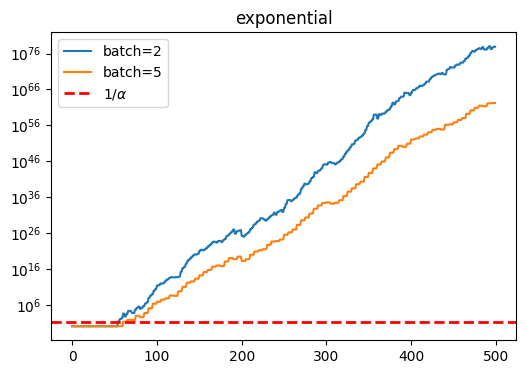

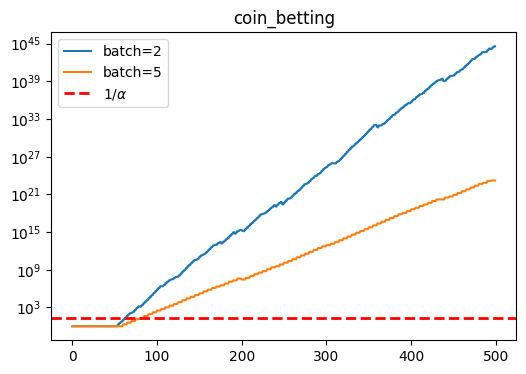

In [22]:
import matplotlib.pyplot as plt
alpha = 0.05
for strategy_name in betting_strategies.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j, :],
            label=f"batch={b}"
        )
    plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()

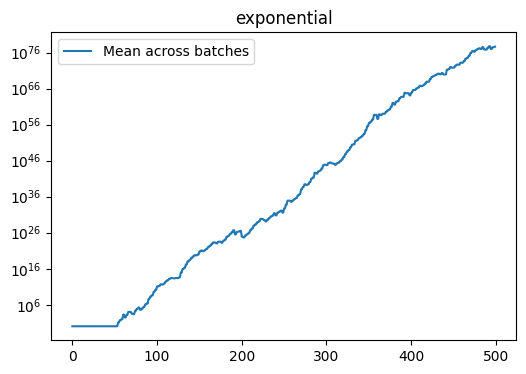

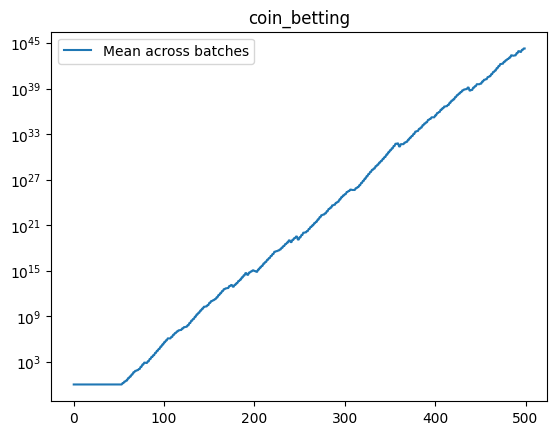

In [23]:
plt.figure(figsize=(6, 4))
j = 0
for strategy_name in betting_strategies.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j, :] for b in batch_list],
        axis=0
    )
    plt.plot(mean_process, label="Mean across batches")
    plt.yscale("log")
    plt.title(strategy_name)
    plt.legend()
    plt.show()

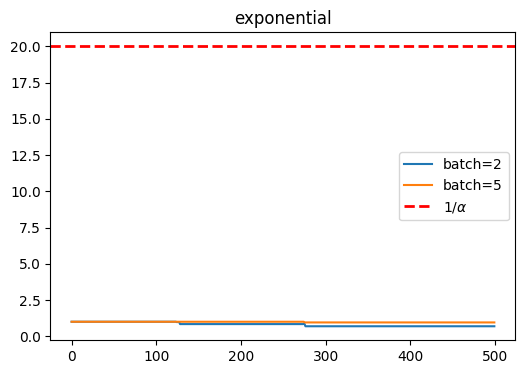

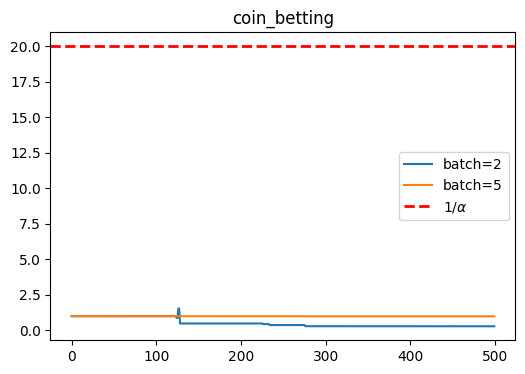

In [25]:
import matplotlib.pyplot as plt
alpha = 0.05
j = 1
for strategy_name in betting_strategies.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j, :],
            label=f"batch={b}"
        )
    #plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()